# 🏆 18. Feature Engineering: RGB + AVG + NTSC Testing SVM

Notebook ini mengevaluasi kinerja final SVM Classifier pada **10.000 sampel testing fitur gabungan (1.536-dimensi)** secara murni (Pure Hold-Out Test Evaluation).
Menampilkan metrik evaluasi komprehensif: Accuracy, Macro Precision, Macro Recall, Macro F1-Score, Classification Report, dan Confusion Matrix.

### 🛡️ Jaminan Integritas Evaluasi (Zero Data Leakage):
- `X_test_scaled` diperoleh murni dari `scaler.transform(X_test_features)`.
- `y_pred_svm` diperoleh murni dari `svm_model.predict(X_test_scaled)`.
- `y_test` hanya digunakan sebagai referensi ground-truth untuk menghitung skor metrik, classification report, dan confusion matrix.


In [1]:
import os
import sys
import pickle
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)
%matplotlib inline

RANDOM_STATE = 23092026

# ==============================================================================
# 1. Custom Transformer: Multi-Domain Feature Preprocessor (1.536-Dimensi)
# ==============================================================================
class FusedDomainPreprocessor(BaseEstimator, TransformerMixin):
    """
    Preprocessor modular untuk fitur gabungan 1.536 dimensi (RGB: 512, AVG: 512, NTSC: 512).
    Mendukung 4 strategi:
      Mode A: 'standard'           -> StandardScaler global (tanpa L2)
      Mode B: 'standard_l2'        -> StandardScaler global + L2 Normalizer
      Mode C: 'per_domain_standard'-> StandardScaler independen per domain + L2 Normalizer
      Mode D: 'domain_weighted'    -> StandardScaler per domain + pembobotan (w_rgb, w_avg, w_ntsc) + optional L2
    """
    def __init__(self, mode='domain_weighted', weights=(1.0, 1.0, 1.0), apply_l2=True):
        self.mode = mode
        self.weights = weights
        self.apply_l2 = apply_l2
        self.scaler_rgb = None
        self.scaler_avg = None
        self.scaler_ntsc = None
        self.scaler_global = None
        self.normalizer = Normalizer(norm='l2') if apply_l2 else None

    def fit(self, X, y=None):
        if self.mode in ['per_domain_standard', 'domain_weighted']:
            self.scaler_rgb = StandardScaler().fit(X[:, :512])
            self.scaler_avg = StandardScaler().fit(X[:, 512:1024])
            self.scaler_ntsc = StandardScaler().fit(X[:, 1024:1536])
        else:
            self.scaler_global = StandardScaler().fit(X)
        return self

    def transform(self, X):
        w_rgb, w_avg, w_ntsc = self.weights
        if self.scaler_global is not None:
            X_scaled = self.scaler_global.transform(X)
            if self.mode == 'domain_weighted':
                X_scaled[:, :512] *= w_rgb
                X_scaled[:, 512:1024] *= w_avg
                X_scaled[:, 1024:1536] *= w_ntsc
            out = X_scaled
        else:
            x_rgb = self.scaler_rgb.transform(X[:, :512]) * w_rgb
            x_avg = self.scaler_avg.transform(X[:, 512:1024]) * w_avg
            x_ntsc = self.scaler_ntsc.transform(X[:, 1024:1536]) * w_ntsc
            out = np.hstack([x_rgb, x_avg, x_ntsc])

        if self.apply_l2 and self.normalizer is not None:
            out = self.normalizer.transform(out)
        return out

# ==============================================================================
# 2. Hierarchical Specialist Classifier (Optional Architecture)
# ==============================================================================
class HierarchicalSpecialistClassifier(BaseEstimator, ClassifierMixin):
    """
    Hierarchical Classifier untuk CIFAR-10:
    - Base classifier: Multiclass SVM pada ruang 1.536 dimensi
    - Specialist 1: Binary SVM khusus membedakan Cat (3) vs Dog (5)
    - Specialist 2: Binary SVM khusus membedakan Automobile (1) vs Truck (9)
    """
    def __init__(self, base_model, specialist_cat_dog=None, specialist_auto_truck=None, use_specialist=False):
        self.base_model = base_model
        self.specialist_cat_dog = specialist_cat_dog
        self.specialist_auto_truck = specialist_auto_truck
        self.use_specialist = use_specialist

    def fit_specialists(self, X_scaled, y):
        # 1. Specialist cat (3) vs dog (5)
        mask_cd = np.isin(y, [3, 5])
        if np.sum(mask_cd) > 0:
            print(f"Melatih Specialist Cat-vs-Dog pada {np.sum(mask_cd)} sampel data training...")
            self.specialist_cat_dog = SVC(C=10.0, gamma='scale', kernel='rbf', random_state=RANDOM_STATE)
            self.specialist_cat_dog.fit(X_scaled[mask_cd], y[mask_cd])

        # 2. Specialist automobile (1) vs truck (9)
        mask_at = np.isin(y, [1, 9])
        if np.sum(mask_at) > 0:
            print(f"Melatih Specialist Auto-vs-Truck pada {np.sum(mask_at)} sampel data training...")
            self.specialist_auto_truck = SVC(C=10.0, gamma='scale', kernel='rbf', random_state=RANDOM_STATE)
            self.specialist_auto_truck.fit(X_scaled[mask_at], y[mask_at])
        return self

    def predict(self, X_scaled):
        preds = self.base_model.predict(X_scaled)
        if not self.use_specialist:
            return preds

        preds = preds.copy()
        if self.specialist_cat_dog is not None:
            cd_idx = np.where(np.isin(preds, [3, 5]))[0]
            if len(cd_idx) > 0:
                preds[cd_idx] = self.specialist_cat_dog.predict(X_scaled[cd_idx])

        if self.specialist_auto_truck is not None:
            at_idx = np.where(np.isin(preds, [1, 9]))[0]
            if len(at_idx) > 0:
                preds[at_idx] = self.specialist_auto_truck.predict(X_scaled[at_idx])

        return preds

    def decision_function(self, X_scaled):
        return self.base_model.decision_function(X_scaled)

ARTIFACT_DIR = 'cifar10_artifacts/rgb_avg_ntsc'
scaler_save_path = os.path.join(ARTIFACT_DIR, 'scaler.pkl')
svm_save_path    = os.path.join(ARTIFACT_DIR, 'svm_model.pkl')
meta_save_path   = os.path.join(ARTIFACT_DIR, 'metadata.json')

def evaluate_classification(y_true, y_pred, title="Classification Evaluation", plot_cm=True, save_cm_path=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    
    classes_name = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
    print("=" * 60)
    print(f"  {title.upper()}")
    print("=" * 60)
    print(f"Akurasi   : {acc * 100:.2f}%")
    print(f"Precision : {prec * 100:.2f}%")
    print(f"Recall    : {rec * 100:.2f}%")
    print(f"F1-Score  : {f1 * 100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=classes_name, digits=4))
    
    cm = confusion_matrix(y_true, y_pred)
    if plot_cm:
        fig, ax = plt.subplots(figsize=(8, 6))
        cax = ax.matshow(cm, cmap='Blues', alpha=0.85)
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(x=j, y=i, s=cm[i, j], va='center', ha='center',
                        color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=9)
        fig.colorbar(cax)
        ax.set_xticks(range(10))
        ax.set_yticks(range(10))
        ax.set_xticklabels(classes_name, rotation=45, ha='left')
        ax.set_yticklabels(classes_name)
        ax.set_xlabel('Predicted Label', fontweight='bold')
        ax.set_ylabel('True Label', fontweight='bold')
        ax.set_title(f'Confusion Matrix: {title} (Acc: {acc*100:.2f}%)', pad=20, fontweight='bold')
        plt.tight_layout()
        if save_cm_path:
            os.makedirs(os.path.dirname(save_cm_path), exist_ok=True)
            plt.savefig(save_cm_path, dpi=150)
        plt.show()
        
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1_macro': f1}

scaler = None
svm_model = None

if os.path.exists(scaler_save_path) and os.path.exists(svm_save_path):
    print(f"Memuat Scaler dari: {scaler_save_path}")
    with open(scaler_save_path, 'rb') as f:
        scaler = pickle.load(f)
    print(f"Memuat SVM Model dari: {svm_save_path}")
    with open(svm_save_path, 'rb') as f:
        svm_model = pickle.load(f)
    print("[BERHASIL] Scaler (Pipeline L2) dan SVM Model berhasil dimuat.")
elif os.path.exists(os.path.join(ARTIFACT_DIR, 'svm_fused_pipeline.pkl')):
    print(f"Memuat model dari fallback: {os.path.join(ARTIFACT_DIR, 'svm_fused_pipeline.pkl')}")
    with open(os.path.join(ARTIFACT_DIR, 'svm_fused_pipeline.pkl'), 'rb') as f:
        p_obj = pickle.load(f)
    if hasattr(p_obj, 'named_steps'):
        scaler = p_obj.named_steps.get('scaler', None)
        svm_model = p_obj.named_steps.get('svm', p_obj)
    else:
        scaler = None
        svm_model = p_obj
    print("[BERHASIL] Model berhasil dimuat.")
else:
    print(f"[INFO] File model belum tersedia di disk.")

if os.path.exists(meta_save_path):
    with open(meta_save_path, 'r') as f:
        metadata = json.load(f)
    print("Metadata Model:", metadata)


Memuat Scaler dari: cifar10_artifacts/rgb_avg_ntsc\scaler.pkl
Memuat SVM Model dari: cifar10_artifacts/rgb_avg_ntsc\svm_model.pkl
[BERHASIL] Scaler (Pipeline L2) dan SVM Model berhasil dimuat.
Metadata Model: {'method': 'Feature Engineering (RGB + AVG + NTSC) + Scaler + SVM', 'fused_components': ['RGB (512)', 'Grayscale AVG (512)', 'Grayscale NTSC (512)'], 'preprocessing_mode': 'domain_weighted', 'feature_weights': [1.0, 0.7, 0.7], 'apply_l2': True, 'use_specialist': False, 'svm_C': 20.0, 'svm_gamma': 'scale', 'total_feature_dim': 1536, 'selection_note': 'Configured and selected based on validation set'}


## 📥 1. Memuat Vektor Fitur Testing Gabungan, Transformasi Scaler & Inferensi SVM


In [2]:
test_feat_path = os.path.join(ARTIFACT_DIR, 'test_features.npz')
test_data = np.load(test_feat_path)
X_test_features = test_data['X_test_features']
y_test = test_data['y_test'].ravel()

print(f"Bentuk fitur testing gabungan: {X_test_features.shape}")
print("1. Menstandarisasi fitur testing dengan scaler training (transform murni, anti-leakage)...")
if scaler is not None:
    X_test_scaled = scaler.transform(X_test_features)
else:
    X_test_scaled = X_test_features

print("2. Menjalankan inferensi SVM murni pada seluruh test set (10.000 sampel)...")
y_pred_svm = svm_model.predict(X_test_scaled)

accuracy = np.mean(y_pred_svm == y_test)
print(f"[BERHASIL] Inferensi SVM selesai! Akurasi: {accuracy * 100:.2f}%")


Bentuk fitur testing gabungan: (10000, 1536)
1. Menstandarisasi fitur testing dengan scaler training (transform murni, anti-leakage)...
2. Menjalankan inferensi SVM murni pada seluruh test set (10.000 sampel)...
[BERHASIL] Inferensi SVM selesai! Akurasi: 94.07%


## 📊 2. Classification Report & Confusion Matrix (SVM Fused)


  RGB + AVG + NTSC FEATURE FUSION SVM EVALUATION
Akurasi   : 94.07%
Precision : 94.07%
Recall    : 94.07%
F1-Score  : 94.07%

Classification Report:
              precision    recall  f1-score   support

    airplane     0.9351    0.9510    0.9430      1000
  automobile     0.9664    0.9770    0.9717      1000
        bird     0.9194    0.9240    0.9217      1000
         cat     0.8696    0.8670    0.8683      1000
        deer     0.9407    0.9520    0.9463      1000
         dog     0.9152    0.8960    0.9055      1000
        frog     0.9580    0.9590    0.9585      1000
       horse     0.9687    0.9580    0.9633      1000
        ship     0.9649    0.9630    0.9640      1000
       truck     0.9687    0.9600    0.9643      1000

    accuracy                         0.9407     10000
   macro avg     0.9407    0.9407    0.9407     10000
weighted avg     0.9407    0.9407    0.9407     10000



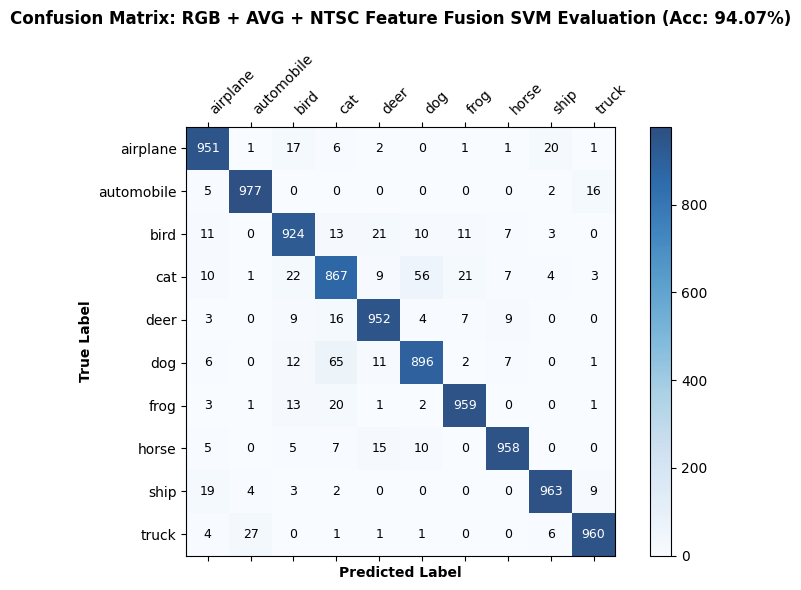


[FINAL RESULT] Feature Fusion (RGB+AVG+NTSC) SVM Test Accuracy: 94.07%
[FINAL RESULT] Feature Fusion (RGB+AVG+NTSC) SVM F1-Score (Macro): 94.07%


In [3]:
cm_path = os.path.join(ARTIFACT_DIR, 'confusion_matrix_svm.png')
metrics_svm = evaluate_classification(
    y_true=y_test,
    y_pred=y_pred_svm,
    title="RGB + AVG + NTSC Feature Fusion SVM Evaluation",
    plot_cm=True,
    save_cm_path=cm_path
)

os.makedirs(ARTIFACT_DIR, exist_ok=True)
with open(os.path.join(ARTIFACT_DIR, 'metrics_svm.json'), 'w') as f:
    json.dump(metrics_svm, f, indent=2)

print()
print(f"[FINAL RESULT] Feature Fusion (RGB+AVG+NTSC) SVM Test Accuracy: {metrics_svm['accuracy'] * 100:.2f}%")
print(f"[FINAL RESULT] Feature Fusion (RGB+AVG+NTSC) SVM F1-Score (Macro): {metrics_svm['f1_macro'] * 100:.2f}%")


## 📊 3. Perbandingan Master Akurasi Semua Alur: CIFAR-10 CNN vs SVM vs Feature Fusion (1536-D)
Diagram batang komparatif yang memuat hasil evaluasi hold-out test set secara dinamis dari file metrik aktual masing-masing alur.


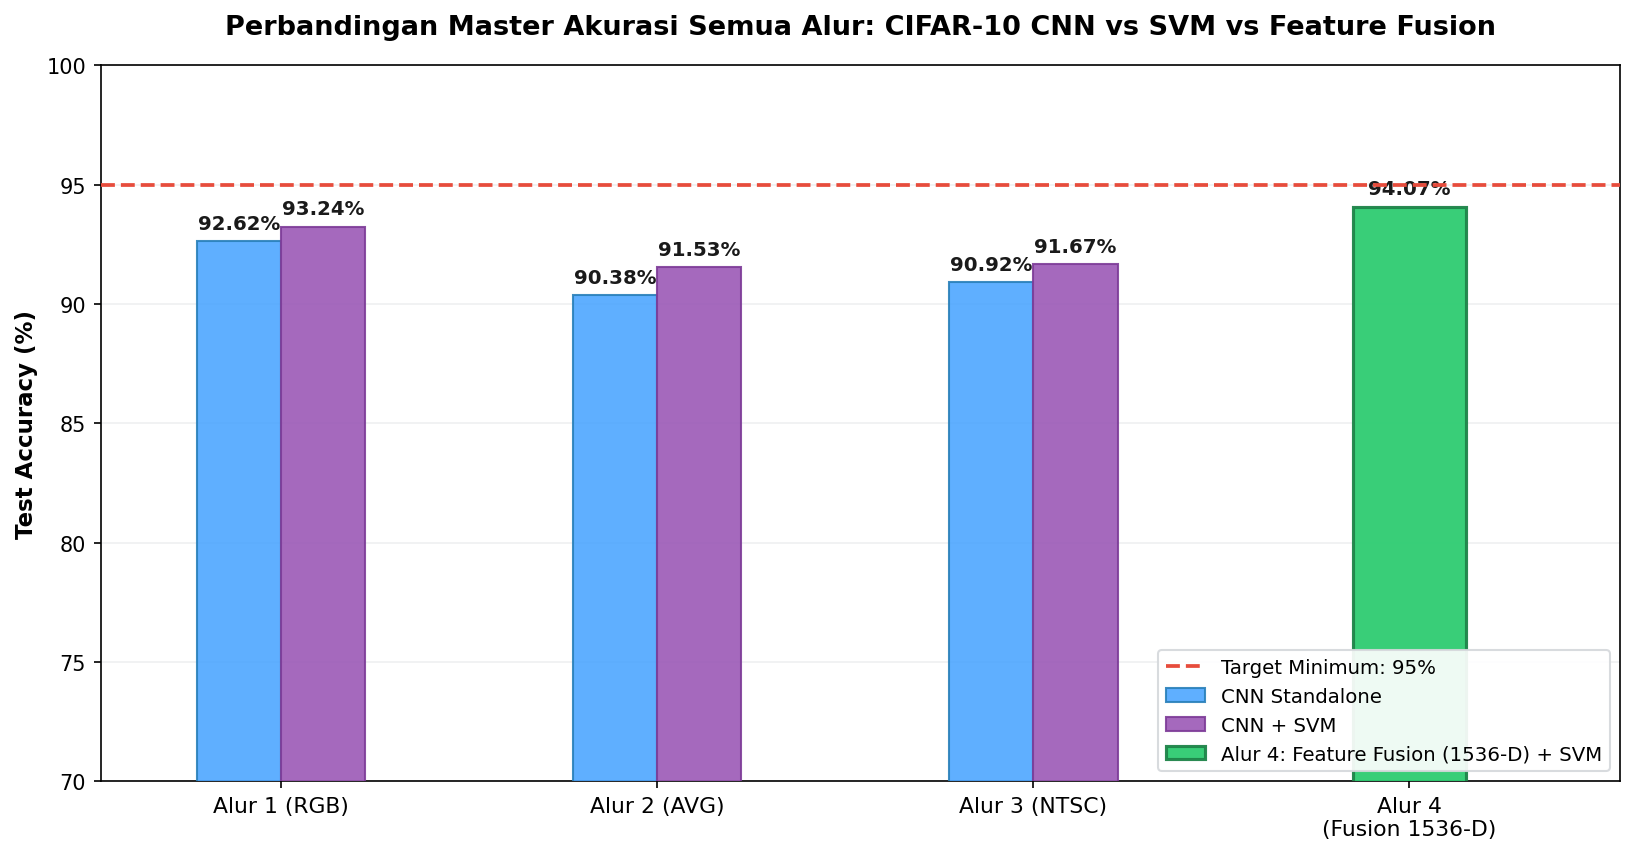

Diagram master akurasi berhasil disimpan ke: cifar10_artifacts/rgb_avg_ntsc\master_accuracy_comparison.png


In [4]:
# Visualisasi Diagram Perbandingan Master Akurasi Semua Alur
import os
import json
import numpy as np
import matplotlib.pyplot as plt

if 'ARTIFACT_DIR' not in globals():
    ARTIFACT_DIR = 'cifar10_artifacts/rgb_avg_ntsc'

# Fungsi pembantu untuk memuat akurasi secara dinamis murni dari file metrik pipeline aktual
def get_metric_acc(dir_path, model_type):
    """
    Membaca akurasi secara dinamis dan murni:
    1. Cek metrics.json (file metrik konsolidasi pipeline aktual).
    2. Cek metrics_{model_type}.json jika metrics.json belum ada.
    Jika kedua file metrik belum ada, raise FileNotFoundError agar tidak menggunakan angka hardcode.
    """
    general_file = os.path.join(dir_path, 'metrics.json')
    if os.path.exists(general_file):
        try:
            with open(general_file, 'r') as f:
                data = json.load(f)
                if model_type == 'cnn':
                    acc = data.get('cnn_test_accuracy', data.get('accuracy', 0))
                else:
                    acc = data.get('svm_test_accuracy', data.get('accuracy', 0))
                if acc > 0.5:
                    return acc * 100 if acc <= 1.0 else acc
        except Exception:
            pass

    specific_file = os.path.join(dir_path, f'metrics_{model_type}.json')
    if os.path.exists(specific_file):
        try:
            with open(specific_file, 'r') as f:
                data = json.load(f)
                acc = data.get('accuracy', 0)
                if acc > 0.5:
                    return acc * 100 if acc <= 1.0 else acc
        except Exception:
            pass

    raise FileNotFoundError(
        f"File metrik evaluasi untuk alur '{dir_path}' ({model_type}) belum ditemukan di disk. "
        f"Silakan jalankan notebook evaluasi alur terkait terlebih dahulu untuk menghasilkan metrik aktual."
    )

# Data Akurasi (%) Alur 1, 2, 3 dimuat secara dinamis murni dari artefak pengujian aktual
cnn_acc = [
    get_metric_acc('cifar10_artifacts/rgb', 'cnn'),
    get_metric_acc('cifar10_artifacts/grayscale_avg', 'cnn'),
    get_metric_acc('cifar10_artifacts/grayscale_ntsc', 'cnn')
]

svm_acc = [
    get_metric_acc('cifar10_artifacts/rgb', 'svm'),
    get_metric_acc('cifar10_artifacts/grayscale_avg', 'svm'),
    get_metric_acc('cifar10_artifacts/grayscale_ntsc', 'svm')
]

# Evaluasi akurasi Feature Fusion (Alur 4) murni dari eksekusi notebook saat ini
if not ('metrics_svm' in globals() and isinstance(metrics_svm, dict) and 'accuracy' in metrics_svm):
    raise RuntimeError(
        "Variabel 'metrics_svm' belum tersedia di memori kernel. "
        "Silakan jalankan Cell 5 (evaluasi SVM aktual) terlebih dahulu sebelum membuat diagram master perbandingan!"
    )

fe_acc = metrics_svm['accuracy'] * 100 if metrics_svm['accuracy'] <= 1.0 else metrics_svm['accuracy']

fig, ax = plt.subplots(figsize=(11, 5.8), dpi=150)

# Kategori dan posisi bar
x = np.array([0, 1.25, 2.5, 3.75])
width = 0.28

# Palet warna
color_cnn = '#4da6ff'       # Sky blue
color_svm = '#9b59b6'       # Soft purple
color_fe = '#2ecc71'        # Vibrant green
color_target = '#e74c3c'    # Red dashed

# Plot Bar Alur 1, 2, 3
bars_cnn = ax.bar(x[:3] - width/2, cnn_acc, width, label='CNN Standalone',
                  color=color_cnn, edgecolor='#2980b9', alpha=0.9, zorder=3)
bars_svm = ax.bar(x[:3] + width/2, svm_acc, width, label='CNN + SVM',
                  color=color_svm, edgecolor='#7d3c98', alpha=0.9, zorder=3)

# Plot Bar Alur 4 (Feature Fusion 1.536-D)
bar_fe = ax.bar(x[3], fe_acc, width * 1.35, label='Alur 4: Feature Fusion (1536-D) + SVM',
                color=color_fe, edgecolor='#1e8449', linewidth=1.5, alpha=0.95, zorder=3)

# Garis Target Minimum 95%
line_target = ax.axhline(y=95.0, color=color_target, linestyle='--', linewidth=1.8,
                         label='Target Minimum: 95%', zorder=4)

# Menambahkan label teks persentase di atas setiap bar
def add_labels(bars):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.2f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 4),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9.5, fontweight='bold', color='#1a1a1a')

add_labels(bars_cnn)
add_labels(bars_svm)
add_labels(bar_fe)

# Format Sumbu dan Grid
ax.set_ylim(70, 100)
ax.set_xlim(-0.6, 4.45)
ax.set_ylabel('Test Accuracy (%)', fontsize=11, fontweight='semibold')
ax.set_title('Perbandingan Master Akurasi Semua Alur: CIFAR-10 CNN vs SVM vs Feature Fusion',
             fontsize=13, fontweight='bold', pad=15)

ax.set_xticks(x)
ax.set_xticklabels([
    'Alur 1 (RGB)',
    'Alur 2 (AVG)',
    'Alur 3 (NTSC)',
    'Alur 4\n(Fusion 1536-D)'
], fontsize=10.5, fontweight='medium')

ax.grid(axis='y', linestyle='-', alpha=0.25, color='#bdc3c7', zorder=0)
ax.set_axisbelow(True)

# Custom Legend
handles = [line_target, bars_cnn, bars_svm, bar_fe]
labels = [
    'Target Minimum: 95%',
    'CNN Standalone',
    'CNN + SVM',
    'Alur 4: Feature Fusion (1536-D) + SVM'
]
ax.legend(handles, labels, loc='lower right', frameon=True,
          facecolor='white', framealpha=0.92, edgecolor='#d5d8dc', fontsize=9.5)

plt.tight_layout()

# Simpan hasil diagram ke direktori artefak
os.makedirs(ARTIFACT_DIR, exist_ok=True)
os.makedirs('cifar10_artifacts', exist_ok=True)
save_path = os.path.join(ARTIFACT_DIR, 'master_accuracy_comparison.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
master_root_path = 'cifar10_artifacts/master_accuracy_comparison.png'
plt.savefig(master_root_path, dpi=300, bbox_inches='tight')

plt.show()
print(f"Diagram master akurasi berhasil disimpan ke: {save_path}")
